# AG2 - Actividad Guiada 2

Nombre: Raúl Sánchez Mondéjar  
Link: https://colab.research.google.com/drive/xxxxxxxxxxxxxxxxxxxxxxxxx  
Github: [https://github.com/rsmondejar/03MIAR_10_B_2025-26_Algoritmos-de-Optimizacion_Actividad_Guiada_2](https://github.com/rsmondejar/03MIAR_10_B_2025-26_Algoritmos-de-Optimizacion_Actividad_Guiada_2)


In [1]:
import math

## Programación Dinámica. Viaje por el rio

- **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
- **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (\*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

### Problema

En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

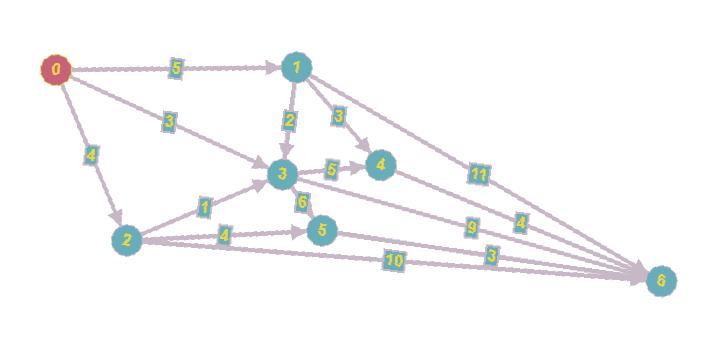


*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)


In [2]:
# Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
    [0, 5, 4, 3, float("inf"), 999, 999],  # desde nodo 0
    [999, 0, 999, 2, 3, 999, 11],  # desde nodo 1
    [999, 999, 0, 1, 999, 4, 10],  # desde nodo 2
    [999, 999, 999, 0, 5, 6, 9],
    [999, 999, 999, 999, 0, 999, 4],
    [999, 999, 999, 999, 999, 0, 3],
    [999, 999, 999, 999, 999, 999, 0]
]

# 999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [3]:
# Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
    ################################################################
    # Total de Nodos
    N = len(TARIFAS[0])

    # Inicialización de la tabla de precios
    PRECIOS = [[9999]*N for i in [9999]*N]  # n x n
    RUTA = [[""]*N for i in [""]*N]

    # Se recorren todos los nodos con dos bucles(origen - destino)
    #  para ir construyendo la matriz de PRECIOS
    for i in range(N-1):
        for j in range(i+1, N):
            MIN = TARIFAS[i][j]
            RUTA[i][j] = i

            for k in range(i, j):
                if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
                    MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j])
                    RUTA[i][j] = k
                PRECIOS[i][j] = MIN

    return PRECIOS, RUTA

In [4]:
PRECIOS, RUTA = Precios(TARIFAS)
# print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
    print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
    print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [5]:
# Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
    if desde == RUTA[desde][hasta]:
        # if desde == hasta:
        # print("Ir a :" + str(desde))
        return desde
    else:
        return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) + ',' + str(RUTA[desde][hasta])


print("\nLa ruta es:")
calcular_ruta(RUTA, 0, 6)


La ruta es:


'0,2,5'

## Problema de Asignacion de tarea


In [6]:
# Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES = [
    [11, 12, 18, 40],
    [14, 15, 13, 22],
    [11, 17, 19, 23],
    [17, 14, 20, 28]
]

In [7]:
# Calculo del valor de una solucion parcial
def valor(S, COSTES):
    VALOR = 0
    for i in range(len(S)):
        VALOR += COSTES[S[i]][i]
    return VALOR


#  Teniendo en cuenta que los indices de columnas y vectores comienzan por cero.
"""En este ejemplo:
- el 3 sería la primera columna y la fila con índice 3, equivaldría al 17
- el 2 sería la segunda columna y la fila con índice 2, equivladría al 17
"""
print(valor((3, 2,), COSTES))

"""En este ejemplo:
- el 0 sería la primera columna y la fila con índice 0, equivaldría al 11
- el 2 sería la segunda columna y la fila con índice 2, equivladría al 17
"""
print(valor((0, 2,), COSTES))

"""En este ejemplo:
- el 3 sería la primera columna y la fila con índice 3, equivaldría al 17
- el 2 sería la segunda columna y la fila con índice 2, equivladría al 17
- el 1 sería la tercera columna y la fila con índice 1, equivaldría al 13
- el 0 sería la cuarta columna y la fila con índice 0, equivladría al 40
"""
print(valor((3, 2, 1, 0), COSTES))

34
28
87


In [8]:
# Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S, COSTES):
    VALOR = 0
    # Valores establecidos
    for i in range(len(S)):
        #  Descomentar esta linea para testear
        # print([i, S[i], COSTES[i][S[i]]])
        VALOR += COSTES[i][S[i]]

    # Estimacion
    for i in range(len(S), len(COSTES)):
        VALOR += min([COSTES[j][i] for j in range(len(S), len(COSTES))])
    return VALOR


def CS(S, COSTES):
    VALOR = 0
    # Valores establecidos
    for i in range(len(S)):
        VALOR += COSTES[i][S[i]]

    # Estimacion
    for i in range(len(S), len(COSTES)):
        #  Descomentar esta linea para testear
        # print([[j, i, COSTES[j][i]] for j in range(len(S), len(COSTES))])
        VALOR += max([COSTES[j][i] for j in range(len(S), len(COSTES))])
    return VALOR


CI((0, 1), COSTES)

68

In [9]:
# Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
# (0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
    HIJOS = []
    for i in range(N):
        if i not in NODO:
            HIJOS.append({'s': NODO + (i,)})
    return HIJOS

In [10]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [11]:
def ramificacion_y_poda(COSTES):
    # Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
    # Nodos del grafo  { s:(1,2),CI:3,CS:5  }
    # print(COSTES)
    DIMENSION = len(COSTES)
    MEJOR_SOLUCION = tuple(i for i in range(len(COSTES)))
    CotaSup = valor(MEJOR_SOLUCION, COSTES)
    # print("Cota Superior:", CotaSup)

    NODOS = []
    NODOS.append({'s': (), 'ci': CI((), COSTES)})

    iteracion = 0

    while (len(NODOS) > 0):
        iteracion += 1

        nodo_prometedor = [min(NODOS, key=lambda x: x['ci'])][0]['s']
        # print("Nodo prometedor:", nodo_prometedor)

        # Ramificacion
        # Se generan los hijos
        HIJOS = [
            {'s': x['s'], 'ci': CI(x['s'], COSTES)}
            for x in crear_hijos(nodo_prometedor, DIMENSION)
        ]

        # Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
        NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION]
        if len(NODO_FINAL) > 0:
            # print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
            if NODO_FINAL[0]['ci'] < CotaSup:
                CotaSup = NODO_FINAL[0]['ci']
                MEJOR_SOLUCION = NODO_FINAL

        # Poda
        HIJOS = [x for x in HIJOS if x['ci'] < CotaSup]

        # Añadimos los hijos
        NODOS.extend(HIJOS)

        # Eliminamos el nodo ramificado
        NODOS = [x for x in NODOS if x['s'] != nodo_prometedor]

    print(
        "La solucion final es:", MEJOR_SOLUCION, " en ",
        iteracion, " iteraciones", " para dimension: ", DIMENSION
    )


ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4


## Descenso del gradiente


In [12]:
import math  # Funciones matematicas
import matplotlib.pyplot as plt  # Generacion de gráficos (otra opcion seaborn)
import numpy as np  # Tratamiento matriz N-dimensionales y otras (fundamental!)
# import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.


In [13]:
# Definimos la funcion
# Paraboloide
f  = lambda X: X[0] ** 2 + X[1] ** 2 #Funcion
df = lambda X: [ 2 *X[0] , 2 * X[1]] #Gradiente

df([1, 2])

[2, 4]

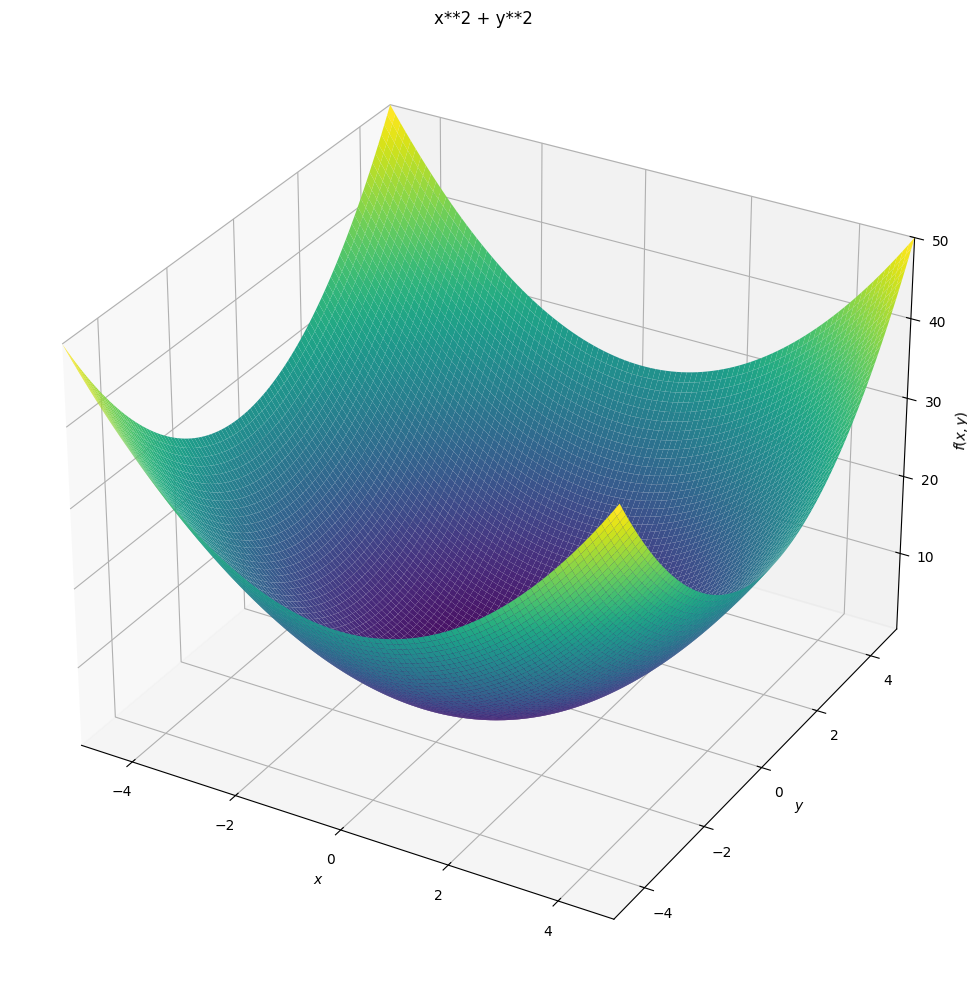

In [14]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d

x, y = symbols('x y')
plot3d(
    x**2 + y**2,
    (x, -5, 5),
    (y, -5, 5),
    title='x**2 + y**2',
    size=(10, 10)
)

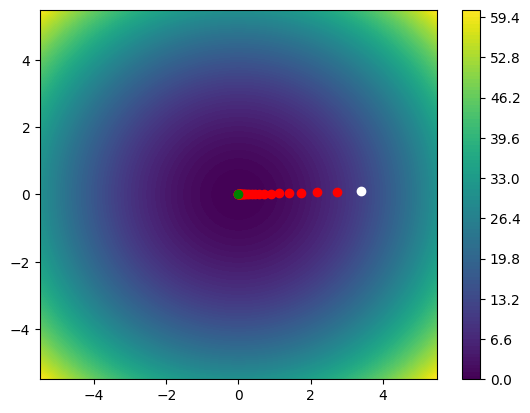

Solucion: [4.865418115843449e-05, 1.5281688918539654e-06] 2.369564644359792e-09


In [15]:
# Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango = 5.5

X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros((resolucion, resolucion))
for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[iy, ix] = f([x, y])

# Pinta el mapa de niveles de Z
plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

# Generamos un punto aleatorio inicial y pintamos de blanco
P = [random.uniform(-5, 5), random.uniform(-5, 5)]
plt.plot(P[0], P[1], "o", c="white")

# Tasa de aprendizaje (Learning Rate). Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA = .1

# Iteraciones:50
for _ in range(50):
    grad = df(P)
    # print(P,grad)
    P[0], P[1] = P[0] - TA*grad[0], P[1] - TA*grad[1]
    plt.plot(P[0], P[1], "o", c="red")

# Dibujamos el punto final y pintamos de verde
plt.plot(P[0], P[1], "o", c="green")
plt.show()
print("Solucion:", P, f(P))

**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
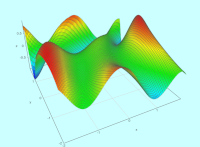


In [16]:
#Definimos la funcion
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )


---
# Mejoras

En esta sección se abordan los puntos adicionales propuestos para mejorar la nota:

**Ramificación y Poda:**
1. Implementación del algoritmo de **fuerza bruta** para el problema de asignación de tareas
2. Análisis de la **complejidad** del algoritmo de fuerza bruta
3. Generación de matrices aleatorias de **mayores dimensiones** (5, 6, 7, ...) y ejecución de ambos algoritmos
4. Determinar a partir de qué dimensión la **fuerza bruta deja de ser viable**
5. Determinar si la **ramificación y poda** también tiene un límite práctico

**Descenso del gradiente:**
6. Minimización de la función $f(x) = \sin(1/2 \cdot x^2 - 1/4 \cdot y^2 + 3) \cdot \cos(2x + 1 - e^y)$ mediante descenso del gradiente

## Mejora 1: Algoritmo de Fuerza Bruta para Asignación de Tareas

### ¿Qué es la fuerza bruta?

El algoritmo de **fuerza bruta** consiste en explorar **todas las posibles asignaciones** de tareas a agentes sin ningún tipo de poda ni optimización. Para N agentes y N tareas, se generan todas las **permutaciones** posibles de asignación.

### ¿Cómo funciona paso a paso?

1. **Generamos todas las permutaciones**: Para N tareas, creamos todas las formas posibles de asignar tareas a agentes. Cada permutación es una tupla donde la posición i indica qué tarea se asigna al agente i.
2. **Calculamos el coste de cada permutación**: Sumamos los costes de cada asignación agente-tarea.
3. **Nos quedamos con la mejor**: La permutación con menor coste total es la solución óptima.

Por ejemplo, con 4 agentes y 4 tareas:
- Permutación (0,1,2,3) significa: Agente 0 → Tarea 0, Agente 1 → Tarea 1, ...
- Permutación (3,2,1,0) significa: Agente 0 → Tarea 3, Agente 1 → Tarea 2, ...
- Se evalúan las 4! = 24 permutaciones posibles

In [17]:
from itertools import permutations
import time

# Algoritmo de Fuerza Bruta para el problema de asignación de tareas
# Explora TODAS las permutaciones posibles y se queda con la mejor
def fuerza_bruta(COSTES):
    DIMENSION = len(COSTES)
    mejor_coste = float("inf")
    mejor_solucion = None
    total_permutaciones = 0
    
    # Generamos todas las permutaciones posibles de (0, 1, 2, ..., N-1)
    # Cada permutación representa una asignación completa de tareas a agentes
    for perm in permutations(range(DIMENSION)):
        total_permutaciones += 1
        
        # Calculamos el coste de esta asignación
        # perm[i] = tarea asignada al agente i
        coste = sum(COSTES[i][perm[i]] for i in range(DIMENSION))
        
        # Si es mejor que la mejor encontrada hasta ahora, la guardamos
        if coste < mejor_coste:
            mejor_coste = coste
            mejor_solucion = perm
    
    print("Fuerza bruta - Solución: {}, Coste: {}, Permutaciones evaluadas: {}, Dimensión: {}".format(
          mejor_solucion, mejor_coste, total_permutaciones, DIMENSION))
    return mejor_solucion, mejor_coste

# Probamos con la misma matriz de costes original de 4x4
print("=== Prueba con la matriz original 4x4 ===")
print("Matriz de costes:")
for fila in COSTES:
    print(fila)
print()
fuerza_bruta(COSTES)


=== Prueba con la matriz original 4x4 ===
Matriz de costes:
[11, 12, 18, 40]
[14, 15, 13, 22]
[11, 17, 19, 23]
[17, 14, 20, 28]

Fuerza bruta - Solución: (0, 2, 3, 1), Coste: 61, Permutaciones evaluadas: 24, Dimensión: 4


((0, 2, 3, 1), 61)

## Mejora 2: ¿Qué complejidad tiene el algoritmo de fuerza bruta?

### Análisis de complejidad

El algoritmo de fuerza bruta tiene una complejidad de **O(N! × N)**:

- **N!** (N factorial): Es el número total de permutaciones que debemos evaluar. Para N elementos, hay N! formas distintas de ordenarlos.
- **× N**: Por cada permutación, necesitamos sumar N costes para calcular el coste total de esa asignación.

### ¿Por qué crece tan rápido?

El factorial es una de las funciones que **más rápido crece** en matemáticas:

| Dimensión (N) | N! (permutaciones) | Crecimiento |
|---|---|---|
| 4 | 24 | Inmediato |
| 5 | 120 | Inmediato |
| 6 | 720 | Inmediato |
| 7 | 5.040 | Inmediato |
| 8 | 40.320 | Fracciones de segundo |
| 9 | 362.880 | ~1 segundo |
| 10 | 3.628.800 | ~10 segundos |
| 11 | 39.916.800 | ~2 minutos |
| 12 | 479.001.600 | ~25 minutos |
| 15 | 1.307.674.368.000 | ~41 años |
| 20 | 2.4 × 10^18 | Más que la edad del universo |

Esto hace que sea una función de complejidad **superexponencial**, mucho peor incluso que O(2^N).

### Comparación con Ramificación y Poda

La ventaja de **Ramificación y Poda** es que:
- **No** explora todas las permutaciones
- Usa **cotas inferiores** (CI) para descartar ramas que no pueden mejorar la mejor solución encontrada
- En la práctica, explora solo una **fracción** del espacio de búsqueda
- Su complejidad en el **peor caso** sigue siendo O(N!), pero en la práctica es mucho menor

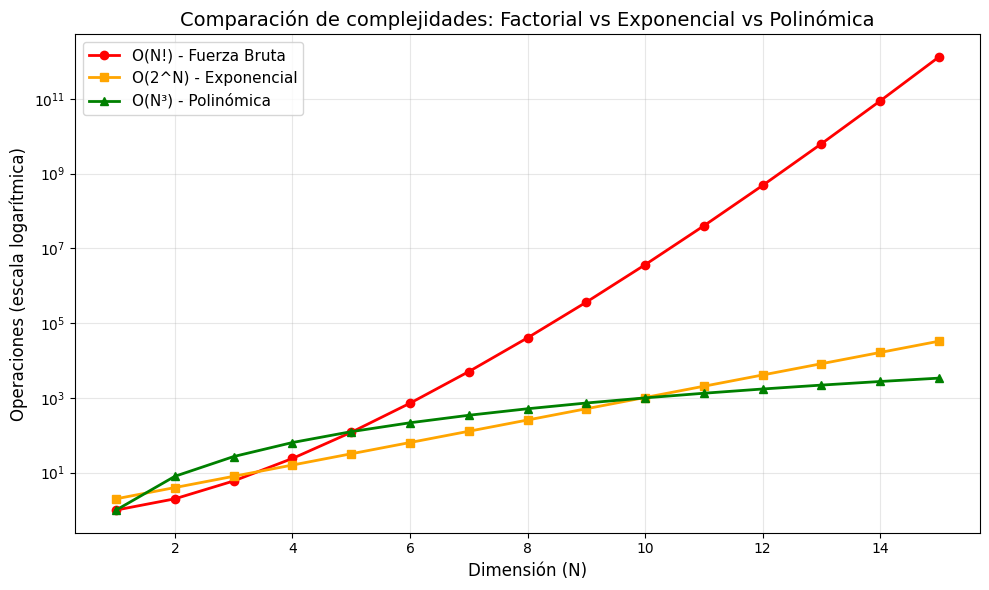

In [18]:
# Visualización del crecimiento factorial vs exponencial
import matplotlib.pyplot as plt
import math

dims = list(range(1, 16))
factorial_vals = [math.factorial(n) for n in dims]
exponential_vals = [2**n for n in dims]
polynomial_vals = [n**3 for n in dims]

plt.figure(figsize=(10, 6))
plt.plot(dims, factorial_vals, "o-", label="O(N!) - Fuerza Bruta", color="red", linewidth=2)
plt.plot(dims, exponential_vals, "s-", label="O(2^N) - Exponencial", color="orange", linewidth=2)
plt.plot(dims, polynomial_vals, "^-", label="O(N³) - Polinómica", color="green", linewidth=2)
plt.yscale("log")
plt.xlabel("Dimensión (N)", fontsize=12)
plt.ylabel("Operaciones (escala logarítmica)", fontsize=12)
plt.title("Comparación de complejidades: Factorial vs Exponencial vs Polinómica", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Mejora 3: Ejecución con matrices aleatorias de mayores dimensiones

### ¿Qué vamos a hacer?

Paso a paso:
1. **Generamos matrices de costes aleatorias** de dimensiones crecientes (5×5, 6×6, 7×7, etc.)
2. **Ejecutamos ambos algoritmos** (fuerza bruta y ramificación y poda) sobre cada matriz
3. **Medimos el tiempo** que tarda cada uno
4. **Comparamos los resultados** para ver cuál es más eficiente

Los valores de la matriz se generan aleatoriamente entre 1 y 50, simulando costes realistas de asignación.

In [19]:
import random
import time

# Función para generar una matriz de costes aleatoria de tamaño NxN
def generar_matriz_costes(N, seed=None):
    """Genera una matriz NxN con costes aleatorios entre 1 y 50."""
    if seed is not None:
        random.seed(seed)
    return [[random.randint(1, 50) for _ in range(N)] for _ in range(N)]


# Versión modificada de ramificación y poda que devuelve resultado y cuenta iteraciones
def ramificacion_y_poda_mejorada(COSTES):
    DIMENSION = len(COSTES)
    MEJOR_SOLUCION = tuple(i for i in range(len(COSTES)))
    CotaSup = valor(MEJOR_SOLUCION, COSTES)
    
    NODOS = []
    NODOS.append({"s": (), "ci": CI((), COSTES)})
    
    iteracion = 0
    
    while len(NODOS) > 0:
        iteracion += 1
        
        nodo_prometedor = [min(NODOS, key=lambda x: x["ci"])][0]["s"]
        
        HIJOS = [
            {"s": x["s"], "ci": CI(x["s"], COSTES)}
            for x in crear_hijos(nodo_prometedor, DIMENSION)
        ]
        
        NODO_FINAL = [x for x in HIJOS if len(x["s"]) == DIMENSION]
        if len(NODO_FINAL) > 0:
            if NODO_FINAL[0]["ci"] < CotaSup:
                CotaSup = NODO_FINAL[0]["ci"]
                MEJOR_SOLUCION = NODO_FINAL
        
        HIJOS = [x for x in HIJOS if x["ci"] < CotaSup]
        NODOS.extend(HIJOS)
        NODOS = [x for x in NODOS if x["s"] != nodo_prometedor]
    
    return MEJOR_SOLUCION, CotaSup, iteracion


# Comparación para dimensiones de 5 a 10
print("=" * 90)
print("{:>4} | {:>10} | {:>12} | {:>12} | {:>10} | {:>10} | {:>12}".format(
    "Dim", "FB Coste", "FB Perms", "FB Tiempo(s)", "RyP Coste", "RyP Iters", "RyP Tiempo(s)"))
print("=" * 90)

resultados = []

for N in range(5, 11):
    # Generamos la misma matriz para ambos algoritmos (misma seed)
    COSTES_TEST = generar_matriz_costes(N, seed=42+N)
    
    # --- Fuerza Bruta ---
    inicio = time.time()
    mejor_perm = None
    mejor_coste_fb = float("inf")
    total_perms = 0
    
    for perm in permutations(range(N)):
        total_perms += 1
        coste = sum(COSTES_TEST[i][perm[i]] for i in range(N))
        if coste < mejor_coste_fb:
            mejor_coste_fb = coste
            mejor_perm = perm
    
    tiempo_fb = time.time() - inicio
    
    # --- Ramificación y Poda ---
    inicio = time.time()
    sol_ryp, coste_ryp, iters_ryp = ramificacion_y_poda_mejorada(COSTES_TEST)
    tiempo_ryp = time.time() - inicio
    
    resultados.append({
        "dim": N,
        "fb_coste": mejor_coste_fb,
        "fb_perms": total_perms,
        "fb_tiempo": tiempo_fb,
        "ryp_coste": coste_ryp,
        "ryp_iters": iters_ryp,
        "ryp_tiempo": tiempo_ryp
    })
    
    print("{:>4} | {:>10} | {:>12,} | {:>12.4f} | {:>10} | {:>10,} | {:>12.4f}".format(
        N, mejor_coste_fb, total_perms, tiempo_fb, coste_ryp, iters_ryp, tiempo_ryp))

print("=" * 90)


 Dim |   FB Coste |     FB Perms | FB Tiempo(s) |  RyP Coste |  RyP Iters | RyP Tiempo(s)
   5 |         56 |          120 |       0.0001 |         56 |         21 |       0.0001
   6 |         64 |          720 |       0.0003 |         64 |         41 |       0.0003
   7 |         75 |        5,040 |       0.0026 |         94 |         93 |       0.0010


   8 |         57 |       40,320 |       0.0220 |         57 |      1,547 |       0.0929


   9 |         76 |      362,880 |       0.2174 |         78 |      2,251 |       0.2033


  10 |         63 |    3,628,800 |       2.2687 |         63 |      2,790 |       0.3142


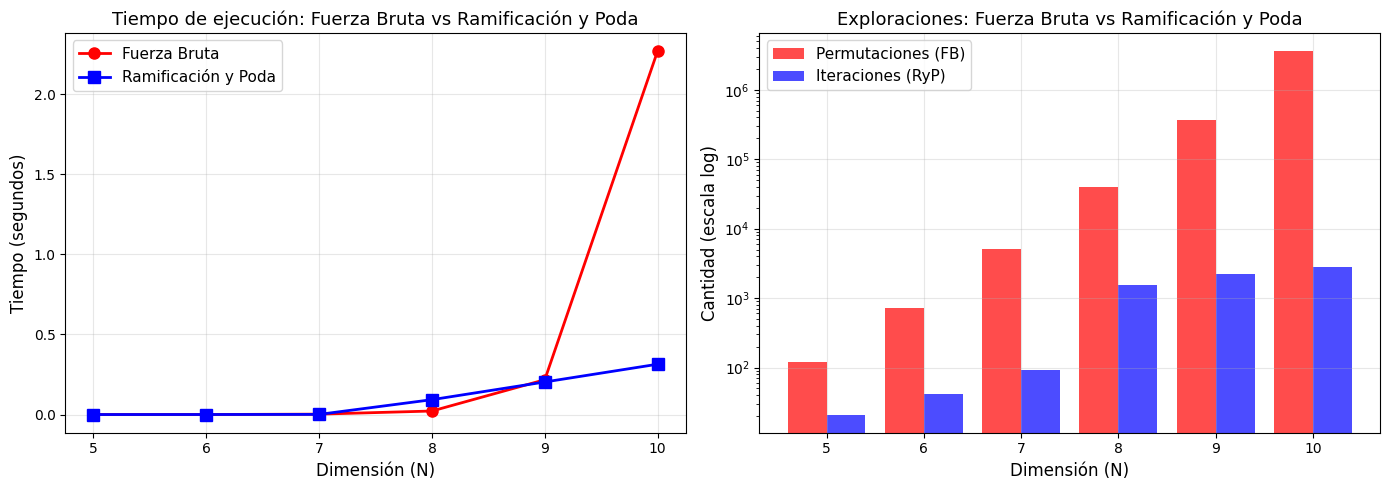

In [20]:
# Gráfica comparativa de tiempos
import matplotlib.pyplot as plt

dims = [r["dim"] for r in resultados]
tiempos_fb = [r["fb_tiempo"] for r in resultados]
tiempos_ryp = [r["ryp_tiempo"] for r in resultados]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Tiempos de ejecución
axes[0].plot(dims, tiempos_fb, "o-", label="Fuerza Bruta", color="red", linewidth=2, markersize=8)
axes[0].plot(dims, tiempos_ryp, "s-", label="Ramificación y Poda", color="blue", linewidth=2, markersize=8)
axes[0].set_xlabel("Dimensión (N)", fontsize=12)
axes[0].set_ylabel("Tiempo (segundos)", fontsize=12)
axes[0].set_title("Tiempo de ejecución: Fuerza Bruta vs Ramificación y Poda", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Nodos/permutaciones explorados
perms_fb = [r["fb_perms"] for r in resultados]
iters_ryp = [r["ryp_iters"] for r in resultados]

axes[1].bar([d - 0.2 for d in dims], perms_fb, 0.4, label="Permutaciones (FB)", color="red", alpha=0.7)
axes[1].bar([d + 0.2 for d in dims], iters_ryp, 0.4, label="Iteraciones (RyP)", color="blue", alpha=0.7)
axes[1].set_xlabel("Dimensión (N)", fontsize=12)
axes[1].set_ylabel("Cantidad (escala log)", fontsize=12)
axes[1].set_title("Exploraciones: Fuerza Bruta vs Ramificación y Poda", fontsize=13)
axes[1].set_yscale("log")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Mejora 4: ¿A partir de qué dimensión la fuerza bruta deja de ser una opción?

### Análisis experimental

Vamos a ejecutar fuerza bruta con dimensiones crecientes y establecer un **límite de tiempo** de 30 segundos. Cuando el algoritmo supere ese límite, consideraremos que deja de ser una opción viable.

### ¿Por qué deja de ser viable?

Recordemos que el número de permutaciones crece como N!:
- Para N=10: 3.628.800 permutaciones
- Para N=11: 39.916.800 permutaciones (11 veces más)
- Para N=12: 479.001.600 permutaciones (12 veces más que N=11)

Cada vez que aumentamos la dimensión en 1, el tiempo se multiplica aproximadamente por N+1. Esto hace que el algoritmo sea **inviable en la práctica** para dimensiones moderadas.

In [21]:
import math

# Determinar el límite práctico de la fuerza bruta
# Usamos un timeout de 15 segundos como límite razonable
TIMEOUT = 15  # segundos

print("Buscando el límite práctico de la fuerza bruta (timeout: {}s)...".format(TIMEOUT))
print("=" * 70)

for N in range(5, 13):
    COSTES_TEST = generar_matriz_costes(N, seed=100+N)
    num_perms = math.factorial(N)
    
    print("\nDimensión {}x{} ({:,} permutaciones):".format(N, N, num_perms))
    
    inicio = time.time()
    mejor_coste = float("inf")
    evaluadas = 0
    timeout_alcanzado = False
    
    for perm in permutations(range(N)):
        evaluadas += 1
        coste = sum(COSTES_TEST[i][perm[i]] for i in range(N))
        if coste < mejor_coste:
            mejor_coste = coste
        
        # Verificar timeout cada 100.000 permutaciones
        if evaluadas % 100000 == 0:
            if time.time() - inicio > TIMEOUT:
                timeout_alcanzado = True
                break
    
    tiempo = time.time() - inicio
    
    if timeout_alcanzado:
        print("  TIMEOUT alcanzado tras {:.2f}s".format(tiempo))
        print("  Solo se evaluaron {:,} de {:,} permutaciones ({:.2f}%)".format(
            evaluadas, num_perms, evaluadas/num_perms*100))
        print("  Tiempo estimado total: {:.0f} segundos".format(tiempo * num_perms / evaluadas))
        print("\n>> CONCLUSION: A partir de dimensión {}, la fuerza bruta deja de ser viable.".format(N))
        break
    else:
        print("  Completado en {:.4f}s - Coste óptimo: {}".format(tiempo, mejor_coste))


Buscando el límite práctico de la fuerza bruta (timeout: 15s)...

Dimensión 5x5 (120 permutaciones):
  Completado en 0.0001s - Coste óptimo: 70

Dimensión 6x6 (720 permutaciones):
  Completado en 0.0004s - Coste óptimo: 64

Dimensión 7x7 (5,040 permutaciones):
  Completado en 0.0028s - Coste óptimo: 59

Dimensión 8x8 (40,320 permutaciones):
  Completado en 0.0237s - Coste óptimo: 60

Dimensión 9x9 (362,880 permutaciones):


  Completado en 0.2263s - Coste óptimo: 66

Dimensión 10x10 (3,628,800 permutaciones):


  Completado en 2.3518s - Coste óptimo: 68

Dimensión 11x11 (39,916,800 permutaciones):


  TIMEOUT alcanzado tras 15.02s
  Solo se evaluaron 22,000,000 de 39,916,800 permutaciones (55.11%)
  Tiempo estimado total: 27 segundos

>> CONCLUSION: A partir de dimensión 11, la fuerza bruta deja de ser viable.


## Mejora 5: ¿La ramificación y poda también deja de ser viable?

### ¿Por qué podría dejar de ser viable?

Aunque ramificación y poda es **mucho más eficiente** que fuerza bruta gracias a la poda de ramas, su complejidad en el **peor caso sigue siendo O(N!)**. Esto ocurre cuando:

- Las cotas inferiores no son suficientemente ajustadas
- Muchas ramas tienen costes similares, por lo que la poda es poco efectiva
- La estructura del problema no permite descartar ramas tempranamente

Vamos a probarlo con dimensiones crecientes para ver cuándo empieza a ser lento.

In [22]:
import threading
import time

# Determinar el límite práctico de Ramificación y Poda
TIMEOUT = 30  # segundos como límite razonable

print("Buscando el límite práctico de Ramificación y Poda (timeout: {}s)...".format(TIMEOUT))
print("=" * 70)

resultados_ryp = []

for N in range(5, 18):
    COSTES_TEST = generar_matriz_costes(N, seed=100+N)
    
    print("\nDimensión {}x{}:".format(N, N))
    
    inicio = time.time()
    resultado_holder = [None, None, None]  # sol, coste, iters
    error_holder = [None]
    
    def ejecutar_ryp():
        try:
            sol, coste, iters = ramificacion_y_poda_mejorada(COSTES_TEST)
            resultado_holder[0] = sol
            resultado_holder[1] = coste
            resultado_holder[2] = iters
        except Exception as e:
            error_holder[0] = e
    
    hilo = threading.Thread(target=ejecutar_ryp)
    hilo.daemon = True
    hilo.start()
    hilo.join(timeout=TIMEOUT)
    
    tiempo = time.time() - inicio
    
    if hilo.is_alive():
        print("  TIMEOUT alcanzado tras {:.2f}s".format(tiempo))
        print("\n>> CONCLUSION: A partir de dimensión {},".format(N))
        print("   Ramificación y Poda empieza a ser lento (>{}s).".format(TIMEOUT))
        resultados_ryp.append({"dim": N, "tiempo": tiempo, "iters": 0, "viable": False})
        break
    elif error_holder[0] is not None:
        print("  Error tras {:.2f}s: {}".format(tiempo, error_holder[0]))
        break
    else:
        coste = resultado_holder[1]
        iters = resultado_holder[2]
        print("  Completado en {:.4f}s - Coste: {} - Iteraciones: {:,}".format(tiempo, coste, iters))
        resultados_ryp.append({"dim": N, "tiempo": tiempo, "iters": iters, "viable": True})

print("\n" + "=" * 70)
print("\nResumen de tiempos de Ramificación y Poda:")
for r in resultados_ryp:
    estado = "OK" if r["viable"] else "LENTO"
    print("  N={:>2}: {:>8.4f}s  ({:>10,} iteraciones) [{}]".format(
        r["dim"], r["tiempo"], r["iters"], estado))


Buscando el límite práctico de Ramificación y Poda (timeout: 30s)...

Dimensión 5x5:
  Completado en 0.0002s - Coste: 79 - Iteraciones: 21

Dimensión 6x6:
  Completado en 0.0004s - Coste: 64 - Iteraciones: 25

Dimensión 7x7:
  Completado en 0.0005s - Coste: 59 - Iteraciones: 44

Dimensión 8x8:
  Completado en 0.0019s - Coste: 74 - Iteraciones: 157

Dimensión 9x9:


  Completado en 1.2444s - Coste: 70 - Iteraciones: 6,207

Dimensión 10x10:


  Completado en 0.2657s - Coste: 68 - Iteraciones: 2,634

Dimensión 11x11:


  Completado en 4.2597s - Coste: 103 - Iteraciones: 11,805

Dimensión 12x12:


  Completado en 0.5290s - Coste: 84 - Iteraciones: 3,708

Dimensión 13x13:


  TIMEOUT alcanzado tras 30.02s

>> CONCLUSION: A partir de dimensión 13,
   Ramificación y Poda empieza a ser lento (>30s).


Resumen de tiempos de Ramificación y Poda:
  N= 5:   0.0002s  (        21 iteraciones) [OK]
  N= 6:   0.0004s  (        25 iteraciones) [OK]
  N= 7:   0.0005s  (        44 iteraciones) [OK]
  N= 8:   0.0019s  (       157 iteraciones) [OK]
  N= 9:   1.2444s  (     6,207 iteraciones) [OK]
  N=10:   0.2657s  (     2,634 iteraciones) [OK]
  N=11:   4.2597s  (    11,805 iteraciones) [OK]
  N=12:   0.5290s  (     3,708 iteraciones) [OK]
  N=13:  30.0160s  (         0 iteraciones) [LENTO]


### Conclusiones sobre los límites de ambos algoritmos

| Algoritmo | Complejidad | Límite práctico aproximado | Razón |
|---|---|---|---|
| Fuerza Bruta | O(N! × N) | ~10-12 | El factorial crece de forma superexponencial |
| Ramificación y Poda | O(N!) peor caso, mucho menos en práctica | ~15-20 | La poda reduce el espacio, pero el peor caso sigue siendo factorial |

**Resumen:**
- La **fuerza bruta** deja de ser viable para dimensiones relativamente pequeñas (~10-12)
- La **ramificación y poda** extiende significativamente el rango de dimensiones que podemos resolver, pero también tiene un límite
- Para problemas de mayor dimensión, se necesitan **heurísticas** (algoritmos genéticos, simulated annealing, etc.) o algoritmos especializados como el **Método Húngaro** que resuelve el problema de asignación en O(N³)

---
## Mejora 6: Minimización de función compleja por descenso del gradiente

### La función a minimizar

68744f(x, y) = \sin\left(rac{1}{2}x^2 - rac{1}{4}y^2 + 3ight) \cdot \cos\left(2x + 1 - e^yight)68744

### ¿Por qué es más difícil que el paraboloide?

A diferencia del paraboloide (x) = x^2 + y^2$ que tiene **un único mínimo global** en (0,0), esta función:

1. **Tiene múltiples mínimos locales**: La combinación de seno y coseno crea una superficie ondulada con muchos valles
2. **No es convexa**: El descenso del gradiente puede quedar atrapado en mínimos locales
3. **El gradiente es complejo**: Hay que aplicar regla de la cadena y regla del producto

### Cálculo del gradiente paso a paso

Usando la regla del producto: $rac{\partial f}{\partial x} = rac{\partial \sin(u)}{\partial x} \cdot \cos(v) + \sin(u) \cdot rac{\partial \cos(v)}{\partial x}$

Donde:
-  = rac{1}{2}x^2 - rac{1}{4}y^2 + 3$
-  = 2x + 1 - e^y$

Las derivadas parciales son:
- $rac{\partial f}{\partial x} = \cos(u) \cdot x \cdot \cos(v) + \sin(u) \cdot (-\sin(v)) \cdot 2$
- $rac{\partial f}{\partial y} = \cos(u) \cdot (-rac{1}{2}y) \cdot \cos(v) + \sin(u) \cdot (-\sin(v)) \cdot (-e^y)$

### Estrategia: múltiples puntos iniciales

Como la función tiene múltiples mínimos locales, ejecutaremos el descenso del gradiente desde **varios puntos iniciales aleatorios** y nos quedaremos con el mejor resultado.

In [23]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

# Definimos la función
# f(x,y) = sin(1/2 * x² - 1/4 * y² + 3) * cos(2*x + 1 - e^y)
f = lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.cos(2*X[0] + 1 - math.exp(X[1]))

# Calculamos el gradiente analíticamente usando la regla del producto:
# f = sin(u) * cos(v)
# df/dx = cos(u)*du/dx * cos(v) + sin(u) * (-sin(v))*dv/dx
# df/dy = cos(u)*du/dy * cos(v) + sin(u) * (-sin(v))*dv/dy
#
# Donde:
#   u = 1/2*x² - 1/4*y² + 3
#   v = 2*x + 1 - e^y
#   du/dx = x
#   du/dy = -1/2 * y
#   dv/dx = 2
#   dv/dy = -e^y

def df(X):
    x, y = X[0], X[1]
    u = 1/2 * x**2 - 1/4 * y**2 + 3
    v = 2*x + 1 - math.exp(y)
    
    # Derivada parcial respecto a x
    dfdx = math.cos(u) * x * math.cos(v) + math.sin(u) * (-math.sin(v)) * 2
    
    # Derivada parcial respecto a y
    dfdy = math.cos(u) * (-1/2 * y) * math.cos(v) + math.sin(u) * (-math.sin(v)) * (-math.exp(y))
    
    return [dfdx, dfdy]

print("Función definida: f(x,y) = sin(1/2*x^2 - 1/4*y^2 + 3) * cos(2*x + 1 - e^y)")
print("f(0, 0) = {:.6f}".format(f([0, 0])))
print("Gradiente en (0, 0) = {}".format(df([0, 0])))


Función definida: f(x,y) = sin(1/2*x^2 - 1/4*y^2 + 3) * cos(2*x + 1 - e^y)
f(0, 0) = 0.141120
Gradiente en (0, 0) = [-0.0, 0.0]


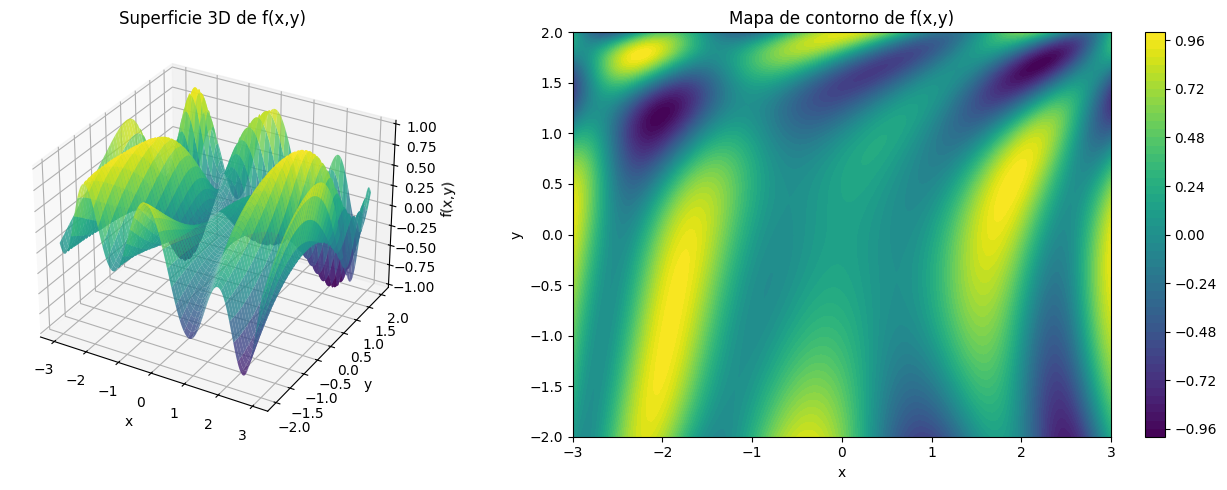

In [24]:
# Visualización 3D de la función
from mpl_toolkits.mplot3d import Axes3D

resolucion = 200
rango_x = 3
rango_y = 2  # Limitamos y porque e^y crece muy rápido

X_vals = np.linspace(-rango_x, rango_x, resolucion)
Y_vals = np.linspace(-rango_y, rango_y, resolucion)
Z_vals = np.zeros((resolucion, resolucion))

for ix, x in enumerate(X_vals):
    for iy, y in enumerate(Y_vals):
        try:
            Z_vals[iy, ix] = f([x, y])
        except:
            Z_vals[iy, ix] = 0

fig = plt.figure(figsize=(14, 5))

# Vista 3D
ax1 = fig.add_subplot(121, projection="3d")
X_mesh, Y_mesh = np.meshgrid(X_vals, Y_vals)
ax1.plot_surface(X_mesh, Y_mesh, Z_vals, cmap="viridis", alpha=0.8)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x,y)")
ax1.set_title("Superficie 3D de f(x,y)")

# Mapa de contorno
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_vals, Y_vals, Z_vals, 50, cmap="viridis")
plt.colorbar(contour, ax=ax2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Mapa de contorno de f(x,y)")

plt.tight_layout()
plt.show()

In [25]:
# Descenso del gradiente con múltiples puntos iniciales
# Como la función tiene múltiples mínimos locales, probamos desde varios puntos

def descenso_gradiente(f, df, punto_inicial, tasa_aprendizaje=0.01, iteraciones=500, tolerancia=1e-8):
    """
    Ejecuta el descenso del gradiente.
    
    Parámetros:
    - f: función a minimizar
    - df: gradiente de la función
    - punto_inicial: [x, y] punto de partida
    - tasa_aprendizaje: tamaño del paso en cada iteración
    - iteraciones: número máximo de iteraciones
    - tolerancia: si el gradiente es menor que esto, paramos (convergencia)
    
    Retorna:
    - punto final, valor de f en ese punto, historial de puntos
    """
    P = list(punto_inicial)
    historial = [list(P)]
    
    for i in range(iteraciones):
        try:
            grad = df(P)
        except (OverflowError, ValueError):
            break
        
        # Verificar convergencia: si el gradiente es muy pequeño, hemos llegado
        magnitud_grad = math.sqrt(grad[0]**2 + grad[1]**2)
        if magnitud_grad < tolerancia:
            break
        
        # Actualizar posición: nos movemos en dirección contraria al gradiente
        P[0] = P[0] - tasa_aprendizaje * grad[0]
        P[1] = P[1] - tasa_aprendizaje * grad[1]
        
        historial.append(list(P))
    
    try:
        valor_final = f(P)
    except (OverflowError, ValueError):
        valor_final = float("inf")
    
    return P, valor_final, historial


# Ejecutamos desde 20 puntos iniciales aleatorios
random.seed(42)
num_intentos = 20
mejor_global = None
mejor_valor_global = float("inf")
mejor_historial = None
todos_los_resultados = []

print("Descenso del gradiente desde múltiples puntos iniciales")
print("=" * 70)

for intento in range(num_intentos):
    # Punto inicial aleatorio en [-3, 3] x [-2, 2]
    x0 = random.uniform(-3, 3)
    y0 = random.uniform(-2, 2)
    
    punto, valor, historial = descenso_gradiente(
        f, df, [x0, y0],
        tasa_aprendizaje=0.01,
        iteraciones=1000
    )
    
    todos_los_resultados.append((punto, valor, historial))
    
    if valor < mejor_valor_global:
        mejor_global = punto
        mejor_valor_global = valor
        mejor_historial = historial
    
    print("Intento {:>2}: Inicio=({:.2f}, {:.2f}) -> Final=({:.4f}, {:.4f}) -> f={:.6f}".format(
        intento+1, x0, y0, punto[0], punto[1], valor))

print("\n" + "=" * 70)
print("\nMEJOR RESULTADO GLOBAL:")
print("  Punto: ({:.6f}, {:.6f})".format(mejor_global[0], mejor_global[1]))
print("  Valor de f: {:.6f}".format(mejor_valor_global))


Descenso del gradiente desde múltiples puntos iniciales
Intento  1: Inicio=(0.84, -1.90) -> Final=(1.0997, -2.8522) -> f=-1.000000
Intento  2: Inicio=(-1.35, -1.11) -> Final=(-0.8936, -0.6967) -> f=-0.038256
Intento  3: Inicio=(1.42, 0.71) -> Final=(2.2018, 1.6871) -> f=-1.000000
Intento  4: Inicio=(2.35, -1.65) -> Final=(2.6736, -2.7282) -> f=-0.999999
Intento  5: Inicio=(-0.47, -1.88) -> Final=(-1.2124, -1.5932) -> f=-0.002360
Intento  6: Inicio=(-1.69, 0.02) -> Final=(-2.0277, 1.1718) -> f=-1.000000
Intento  7: Inicio=(-2.84, -1.20) -> Final=(-2.7062, -1.2199) -> f=-0.000031
Intento  8: Inicio=(0.90, 0.18) -> Final=(2.2018, 1.6871) -> f=-1.000000
Intento  9: Inicio=(-1.68, 0.36) -> Final=(-2.0277, 1.1718) -> f=-1.000000
Intento 10: Inicio=(1.86, -1.97) -> Final=(2.6738, -2.7287) -> f=-0.999999
Intento 11: Inicio=(1.83, 0.79) -> Final=(2.2018, 1.6871) -> f=-1.000000
Intento 12: Inicio=(-0.96, -1.38) -> Final=(-0.9329, -0.8062) -> f=-0.033400
Intento 13: Inicio=(2.74, -0.65) -> Final=

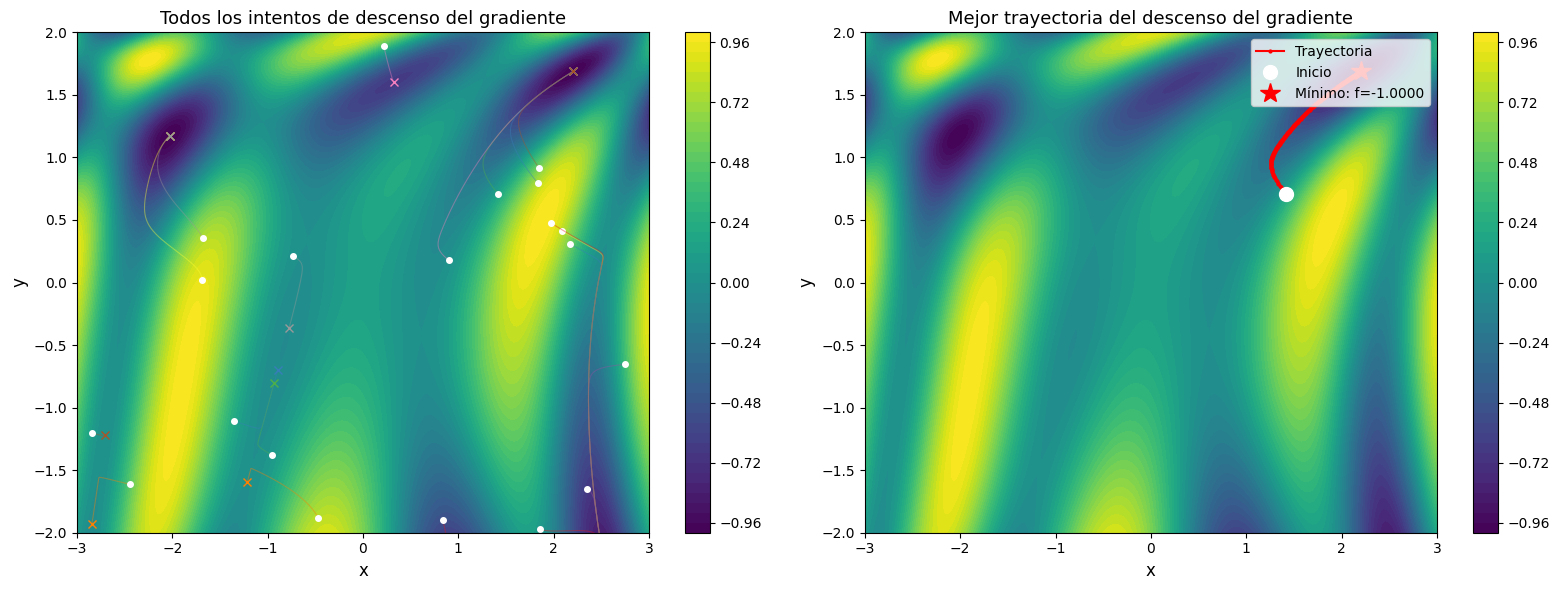


Mínimo encontrado en (2.201787, 1.687060)
Valor de f en el mínimo: -1.000000


In [26]:
# Visualización del descenso del gradiente sobre el mapa de contorno
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfica 1: Todos los intentos ---
ax = axes[0]
contour = ax.contourf(X_vals, Y_vals, Z_vals, 50, cmap="viridis")
plt.colorbar(contour, ax=ax)

# Dibujamos la trayectoria de cada intento
colores = plt.cm.Set1(np.linspace(0, 1, min(num_intentos, 9)))
for idx, (punto, valor, historial) in enumerate(todos_los_resultados):
    h = np.array(historial)
    color = colores[idx % len(colores)]
    ax.plot(h[:, 0], h[:, 1], "-", color=color, alpha=0.4, linewidth=0.8)
    ax.plot(h[0, 0], h[0, 1], "o", color="white", markersize=4)  # Inicio
    ax.plot(h[-1, 0], h[-1, 1], "x", color=color, markersize=6)  # Final

ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_title("Todos los intentos de descenso del gradiente", fontsize=13)
ax.set_xlim(-rango_x, rango_x)
ax.set_ylim(-rango_y, rango_y)

# --- Gráfica 2: Mejor trayectoria ---
ax2 = axes[1]
contour2 = ax2.contourf(X_vals, Y_vals, Z_vals, 50, cmap="viridis")
plt.colorbar(contour2, ax=ax2)

h = np.array(mejor_historial)
ax2.plot(h[:, 0], h[:, 1], "o-", color="red", markersize=2, linewidth=1.5, label="Trayectoria")
ax2.plot(h[0, 0], h[0, 1], "o", color="white", markersize=10, label="Inicio")
ax2.plot(h[-1, 0], h[-1, 1], "*", color="red", markersize=15,
         label="Mínimo: f={:.4f}".format(mejor_valor_global))

ax2.set_xlabel("x", fontsize=12)
ax2.set_ylabel("y", fontsize=12)
ax2.set_title("Mejor trayectoria del descenso del gradiente", fontsize=13)
ax2.legend(fontsize=10, loc="upper right")
ax2.set_xlim(-rango_x, rango_x)
ax2.set_ylim(-rango_y, rango_y)

plt.tight_layout()
plt.show()

print("\nMínimo encontrado en ({:.6f}, {:.6f})".format(mejor_global[0], mejor_global[1]))
print("Valor de f en el mínimo: {:.6f}".format(mejor_valor_global))


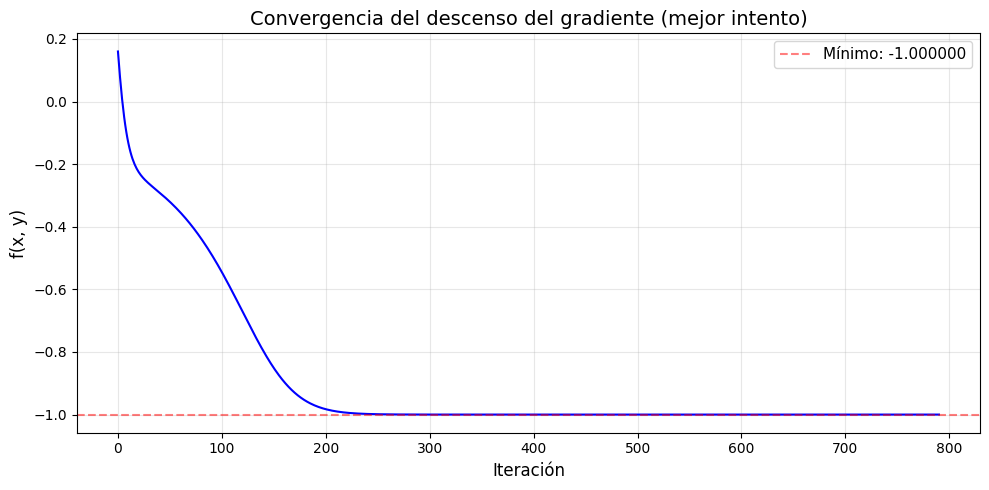

El algoritmo converge desde f(1.42, 0.71) = 0.159876
hasta f(2.201787, 1.687060) = -1.000000
en 791 iteraciones


In [27]:
# Análisis de la convergencia: evolución del valor de f en el mejor intento
valores_f = [f(p) for p in mejor_historial]

plt.figure(figsize=(10, 5))
plt.plot(valores_f, "b-", linewidth=1.5)
plt.xlabel("Iteración", fontsize=12)
plt.ylabel("f(x, y)", fontsize=12)
plt.title("Convergencia del descenso del gradiente (mejor intento)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=mejor_valor_global, color="r", linestyle="--", alpha=0.5,
            label="Mínimo: {:.6f}".format(mejor_valor_global))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("El algoritmo converge desde f({:.2f}, {:.2f}) = {:.6f}".format(
    mejor_historial[0][0], mejor_historial[0][1], valores_f[0]))
print("hasta f({:.6f}, {:.6f}) = {:.6f}".format(
    mejor_global[0], mejor_global[1], mejor_valor_global))
print("en {} iteraciones".format(len(mejor_historial)))


### Conclusiones sobre el descenso del gradiente en funciones complejas

1. **Múltiples mínimos locales**: La función tiene varios mínimos locales. Dependiendo del punto de inicio, el algoritmo converge a diferentes mínimos. Por eso es importante ejecutar desde múltiples puntos iniciales.

2. **Sensibilidad a la tasa de aprendizaje**: Si la tasa es muy grande, el algoritmo puede divergir (especialmente por el término ^y$). Si es muy pequeña, la convergencia es lenta.

3. **El gradiente se calculó analíticamente**: Esto es más preciso y eficiente que aproximarlo numéricamente. Se aplicaron la regla del producto y la regla de la cadena para derivar $\sin(u) \cdot \cos(v)$.

4. **No hay garantía de mínimo global**: A diferencia del paraboloide, esta función no es convexa, por lo que el descenso del gradiente solo encuentra **mínimos locales**. Para encontrar el mínimo global se necesitarían técnicas como:
   - Reinicios aleatorios múltiples (lo que hemos hecho)
   - Simulated Annealing
   - Algoritmos genéticos
   - Optimización por enjambre de partículas